In [ ]:
# Packages installation

!pip install spacy pandas nltk unidecode
!python -m spacy download fr_core_news_sm

print("------------Packages downloaded-----------")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 90.9 MB/s  0:00:00m0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
------------Packages downloaded-----------


In [2]:
# Libraries import
import os
import re
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from IPython.display import display, HTML

In [6]:
#########################Configuration ###########################

# the 1981 parliamentary elections

path_to_files = "/home/onyxia/work/NLP_rendus/.ipynb_checkpoints/data/legislatives_1981"
csv_path="/home/onyxia/work/NLP_rendus/.ipynb_checkpoints/data/legislatives_1981.csv"

# the 1993 parliamentary elections

#csv_path="/home/onyxia/work/NLP_rendus/.ipynb_checkpoints/data/legislatives_1993.csv"
#path_to_files = "/home/onyxia/work/NLP_rendus/.ipynb_checkpoints/data/legislatives_1993"


## Exploration des données

In [7]:
############ Reading the content of the first manifestos #############

# List of .txt files
txt_files = [f for f in os.listdir(path_to_files) if f.endswith(".txt")]


# Loop through the first 5 files and read content

first_five_files = txt_files[:3]

for i, filename in enumerate(first_five_files, 1):
    filepath = os.path.join(path_to_files, filename)
    
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
    
    # 800 first caracters
    raw_preview = content[:800]
    
    # Display preview
    header = f"<h3 style='color: #d9534f; border-bottom: 2px solid #d9534f; padding-bottom: 5px;'>Document {i} : {filename}</h3>"
    
    html_code = f"""
    <div style="
        background-color: #ffffff; 
        color: #333; 
        padding: 20px; 
        border-radius: 8px; 
        box-shadow: 0 4px 6px rgba(0,0,0,0.1);
        font-family: 'Consolas', 'Monaco', monospace;
        font-size: 1em;
        line-height: 1.4;
        border-left: 5px solid #d9534f;
        margin-bottom: 20px;
        /* LE SECRET EST ICI : */
        white-space: pre-wrap; 
        word-wrap: break-word;
    ">
{raw_preview}...
    </div>
    """
    
    display(HTML(header + html_code))

In [8]:
############ Exploring the CSV content #############

df = pd.read_csv(csv_path, encoding="utf-8")

# Column names 
print("--------------- Column names / Attributes --------------")
print(df.columns)


--------------- Column names / Attributes --------------
Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations'],
      d

In [9]:
############ Display the first 5 rows of the csv for columns of interest ################

print("\n--------------- First 5 rows of the DataFrame ---------------")

# List of columns to display
columns_to_show = ['id', 'contexte-election', 'contexte-tour', 'titulaire-soutien', 'titulaire-liste']

# Display only these columns
display(df[columns_to_show].head())



--------------- First 5 rows of the DataFrame ---------------


,id,contexte-election,contexte-tour,titulaire-soutien,titulaire-liste
0,EL134_L_1981_06_001_01_1_PF_01,législatives,1,Parti socialiste unifié,non mentionné
1,EL134_L_1981_06_001_01_1_PF_02,législatives,1,Parti communiste français,Union de la gauche
2,EL134_L_1981_06_001_01_1_PF_03,législatives,1,Parti socialiste;Mouvement des radicaux de gauche,non mentionné
3,EL134_L_1981_06_001_01_1_PF_04,législatives,1,Fédération des socialistes démocrates,non mentionné
4,EL134_L_1981_06_001_01_1_PF_05,législatives,1,Rassemblement pour la République;Union pour la...,Union pour la nouvelle majorité


We will focus on manifestos from the first round of the legislative elections to avoid including alliances, which could introduce confusion and distort the analysis, and to keep more parties, even those that do not reach the second round. This ensures a more accurate and representative prediction of each party’s individual positions, as each party presents its candidates and manifestos independently.

In [12]:
################ Keep only manifestos from the first round ###########################
df_first_round = df[df['contexte-tour'] == 1].copy()

# Reset index for clean dataframe
df_first_round = df_first_round.reset_index(drop=True)


In [13]:
############ data quality check: labelling completeness ############

# This block quantifies metadata "noise" by aggregating missing values (NaN), 
# empty strings, and 'non mentionné' placeholders.

# Columns to check
cols = ['titulaire-soutien', 'titulaire-liste']

for col in cols:
    # Count NaN (missing values)
    num_missing = df_first_round[col].isna().sum()
    
    # Count empty strings
    num_empty = (df_first_round[col] == '').sum()
    
    # Count cells with 'Non mentionné'
    num_non_mentionne = (df_first_round[col] == 'non mentionné').sum()
    
    # Total not mentioned
    total_not_mentioned = num_missing + num_empty + num_non_mentionne
    
    print(f"-- Column '{col}' (1er TOUR) --")
    print(f"Number of modalities 'non mentionné' (NaN, empty, 'non mentionné'): {total_not_mentioned}")
    print(f"Proportion of modalities 'non mentionné' (NaN, empty, 'non mentionné'): {total_not_mentioned/len(df_first_round)}\n")

print("-- Total number of modalities --")
print(f"Total number of rows: {len(df_first_round)}\n")



-- Column 'titulaire-soutien' (1er TOUR) --
Number of modalities 'non mentionné' (NaN, empty, 'non mentionné'): 454
Proportion of modalities 'non mentionné' (NaN, empty, 'non mentionné'): 0.1839546191247974

-- Column 'titulaire-liste' (1er TOUR) --
Number of modalities 'non mentionné' (NaN, empty, 'non mentionné'): 1032
Proportion of modalities 'non mentionné' (NaN, empty, 'non mentionné'): 0.4181523500810373

-- Total number of modalities --
Total number of rows: 2468



In [14]:
########################categorical distribution #########################################
# This function computes the frequency of each political modality (party, support).

def display_counts(df, col_name):
    # Calculate frequency counts and convert the index to a proper column
    counts = df[col_name].value_counts().reset_index()
    counts.columns = ['Modality', 'Count']
    
    # Truncate long strings to 50 characters to prevent table overflow/misalignment
    counts['Modality'] = counts['Modality'].astype(str).apply(
        lambda x: x[:50] + '...' if len(x) > 50 else x
    )
    
    # Display the result
    print(f"\n--- Distribution for: {col_name} (1er tour)---")
    display(counts)

display_counts(df_first_round, 'titulaire-soutien')
display_counts(df_first_round, 'titulaire-liste')


--- Distribution for: titulaire-soutien (1er tour)---


,Modality,Count
0,Parti communiste français,463
1,non mentionné,454
2,Parti socialiste,407
3,Lutte ouvrière,159
4,Parti socialiste unifié,148
...,...,...
217,Combat ouvrier,1
218,Front indépendantiste;Libération Kanak sociali...,1
219,Front indépendantiste,1
220,Comité socialiste calédonien,1



--- Distribution for: titulaire-liste (1er tour)---


,Modality,Count
0,non mentionné,1032
1,Union pour une nouvelle majorité,482
2,Majorité d'union de la gauche,241
3,Majorité de la France,142
4,Union de la gauche,76
...,...,...
114,Pour une nouvelle majorité,1
115,Union pour Saint-Pierre-et-Miquelon,1
116,Front-uni-here-a'ai,1
117,Centre démocratique,1


## Treatment of "Non mentionné" and Analysis of Modalities

To choose beetween the modalities `titulaire-soutien` and `titulaire-liste` in our prediction, we will:

1. **Filter out rows** that are either `NaN`, empty (`""`), or `"Non mentionné"` to create a cleaned dataset.
2. **Count occurrences** of each valid modality and classify them into intervals (bins) according to the number of manifestos:  
   - 0–10, 10–20, 20–30, 30–40, 40–50, 50+
3. Compute **summary tables and histograms**


We subsequently analyze the distribution of manifestos across the most frequent categories to ensure an adequate sample size for robust statistical learning.


In [15]:
################# Data stratification and selection criteria ############################ 

def analyze_category_distribution(df, cols):
    """
    Cleans the dataframe and analyzes the distribution of most frequent modalities 
    """
    categories_30_plus_dict = {}
    
    # Bins
    bins = [0, 10, 20, 30, 40, 50, float('inf')]
    labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50+']
    
    working_df = df.copy()

    for col in cols:
        # Remove invalid entries
        invalid_mask = (working_df[col].isna()) | (working_df[col] == '') | (working_df[col] == 'non mentionné')
        working_df = working_df[~invalid_mask]
        
        print(f"\n--- Analysis for Column: '{col}' ---")
        print(f"Cleaned dataset size: {len(working_df)} rows")
        
        # Count occurrences of each modality
        counts = working_df[col].value_counts()
        
        # Record categories meeting the N>=30 threshold
        num_30_plus = (counts >= 30).sum()
        categories_30_plus_dict[col] = num_30_plus
        print(f"Number of categories with at least 30 manifestos: {num_30_plus}")
        
        # Proportion of usable manifestos
        usable_manifestos = counts[counts >= 30].sum()
        proportion_usable = usable_manifestos / len(df)
        
        binned = pd.cut(counts, bins=bins, labels=labels, right=False)
        
        # Modalities per bin
        summary_modalities = binned.value_counts().sort_index()
        
        # Total manifestos per bin
        summary_manifestos = counts.groupby(binned).sum().reindex(labels).fillna(0).astype(int)
        
        # Summary table
        summary_df = pd.DataFrame({
            'Number of modalities': summary_modalities,
            'Number of manifestos': summary_manifestos
        })
        
        # Add Total row
        total_row = pd.DataFrame({
            'Number of modalities': [summary_df['Number of modalities'].sum()],
            'Number of manifestos': [summary_df['Number of manifestos'].sum()]
        }, index=['Total'])
        
        summary_df = pd.concat([summary_df, total_row])
        display(summary_df)

        # NEW print
        print(f"Proportion of usable manifestos: {proportion_usable:.3f}\n")

        
    return categories_30_plus_dict


# Execution
final_30_plus_stats = analyze_category_distribution(df_first_round, ['titulaire-soutien', 'titulaire-liste'])


--- Analysis for Column: 'titulaire-soutien' ---
Cleaned dataset size: 2014 rows
Number of categories with at least 30 manifestos: 12


/tmp/ipykernel_13622/4140512080.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_manifestos = counts.groupby(binned).sum().reindex(labels).fillna(0).astype(int)


,Number of modalities,Number of manifestos
0-10,206,361
10-20,2,24
20-30,1,22
30-40,3,100
40-50,2,90
50+,7,1417
Total,221,2014


Proportion of usable manifestos: 0.651


--- Analysis for Column: 'titulaire-liste' ---
Cleaned dataset size: 1114 rows
Number of categories with at least 30 manifestos: 7


/tmp/ipykernel_13622/4140512080.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_manifestos = counts.groupby(binned).sum().reindex(labels).fillna(0).astype(int)


,Number of modalities,Number of manifestos
0-10,69,132
10-20,3,46
20-30,2,48
30-40,2,68
40-50,1,45
50+,4,775
Total,81,1114


Proportion of usable manifestos: 0.360



We define usable manifestos as those for which a political affiliation is explicitly reported and that are associated with a representative category, namely a party represented by at least 30 manifestos in the corpus.

According to the previous results, we choose to use titulaire-soutien as the variable to implement our classifier model.

The graph below shows that, for the variable titulaire-liste, most categories that appear in fewer than 30 manifestos occur in fewer than five manifestos. This makes predicting the list affiliation practically infeasible and further supports our choice.

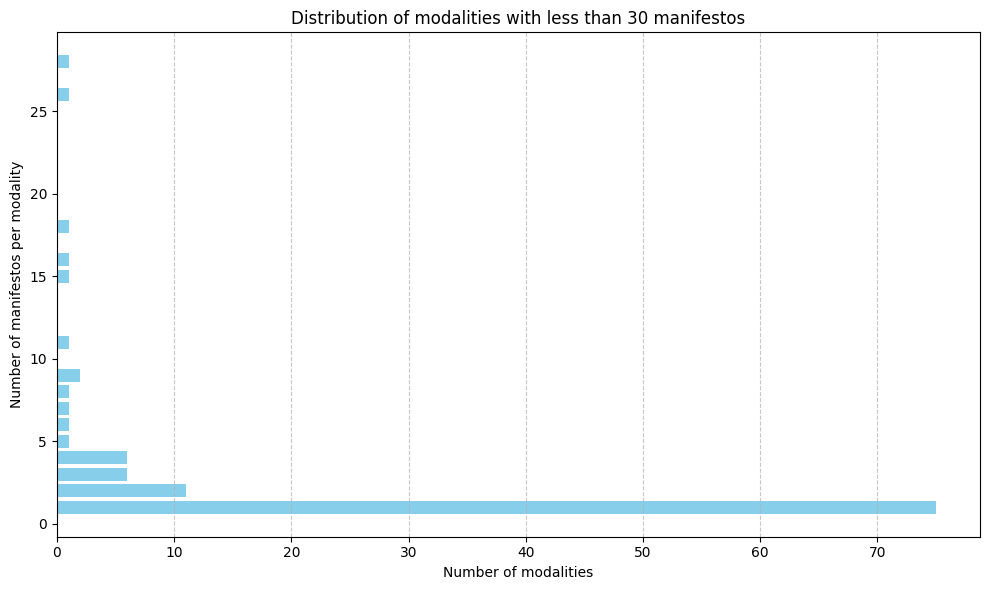

In [16]:
# Count the number of manifestos per modality
counts = df_first_round['titulaire-liste'].value_counts()

# Keep only modalities with strictly less than 30 manifestos
counts_under_30 = counts[counts < 30]

# Count how many modalities have each number of manifestos
freq_of_counts = counts_under_30.value_counts().sort_index()

# Plot horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(freq_of_counts.index, freq_of_counts.values, color='skyblue')
plt.xlabel("Number of modalities")
plt.ylabel("Number of manifestos per modality")
plt.title("Distribution of modalities with less than 30 manifestos")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


From this point onward, we work exclusively with the unified and cleaned dataframe. This dataset, merging the CSV metadata and the text files), includes only categories with more than 30 manifestos and excludes all observations for which the political support is not identified. 


In [18]:
from create_dataframe import prepare_legislatives_dataset

df_final = prepare_legislatives_dataset(csv_path, path_to_files)

print(f"Number of usable manifestos: {len(df_final)}\n")


Number of usable manifestos: 1607



## Statistiques descriptives


--- Summary Table (Verified Categories) ---


,Category,Number of manifestos
0,Parti communiste français,463
1,Parti socialiste,407
2,Lutte ouvrière,159
3,Parti socialiste unifié,148
4,Rassemblement pour la République,104
5,Union pour la démocratie française,70
6,Rassemblement pour la République;Union pour la...,66
7,Mouvement des radicaux de gauche,46
8,Front national,44
9,Union pour la démocratie française;Rassembleme...,38


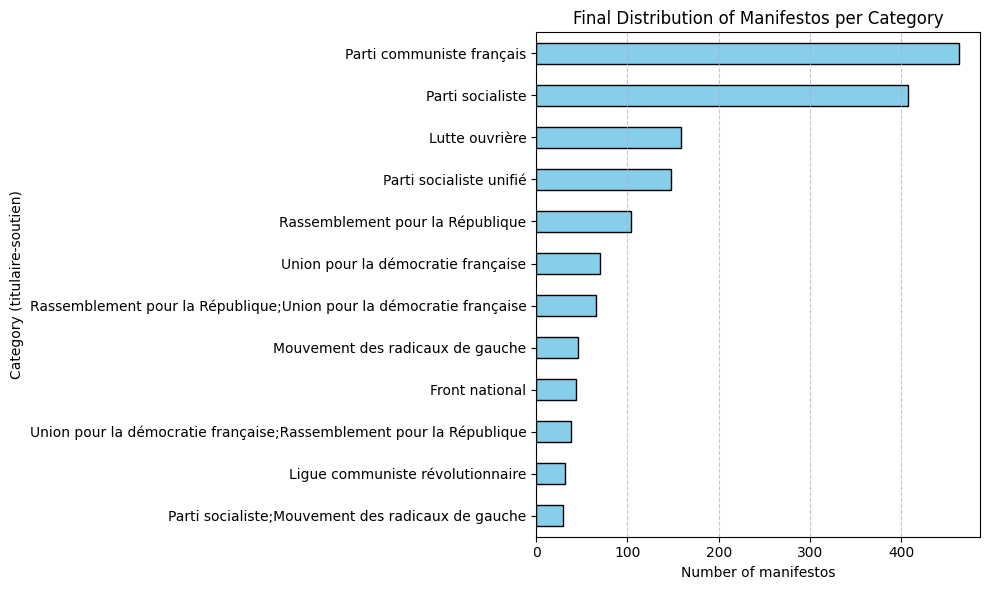

In [19]:
# Counts and visualizes political manifestos for 'titulaire-soutien'
# Only categories with more than 30 manifestos

# Count manifestos from the already filtered dataframe
counts = df_final ['titulaire-soutien'].value_counts()

# Create summary table
summary_df = pd.DataFrame({
    'Category': counts.index,
    'Number of manifestos': counts.values
})

print("\n--- Summary Table (Verified Categories) ---")
display(summary_df) # Use display() for a cleaner table in Notebooks

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
counts.plot(kind='barh', color='skyblue', edgecolor='black')

# Formatting
plt.xlabel("Number of manifestos")
plt.ylabel("Category (titulaire-soutien)")
plt.title("Final Distribution of Manifestos per Category")
plt.gca().invert_yaxis()  # Largest values on top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()



The goal of this module is to:
- Understand the raw structure of the corpus   
- Detect potential OCR or formatting issues 

In [20]:
######################## textual analysis and lexical statistics##############################
## This module processes text content to compute lexical richness and stylistic metrics

def run_textual_analysis(df_input):
    """
    Computes lexical metrics and cleans text. 
    """
    def _preprocess(text):
        text = str(text).lower()
        text = re.sub(r'[^\w\s]', '', text)
        tokens = text.split()
        return [t for t in tokens if t != ""]

    def _count_sentences(text):
        sentences = re.split(r'[.!?]+', str(text))
        return len([s.strip() for s in sentences if s.strip() != ""])

    def _get_hapax_ratio(tokens):
        if not tokens: return 0
        counts = Counter(tokens)
        return sum(1 for w in counts if counts[w] == 1) / len(tokens)

    df = df_input.copy()
    
    # Basic tokens and counts
    df["tokens"] = df["text_content"].apply(_preprocess)
    df["nb_words"] = df["tokens"].apply(len)
    df["nb_sentences"] = df["text_content"].apply(_count_sentences)
    
    # Document-level stats
    df["words_per_sentence"] = df["nb_words"] / df["nb_sentences"].replace(0, np.nan)
    df["vocab_size_doc"] = df["tokens"].apply(lambda x: len(set(x)))
    df["ttr"] = df["vocab_size_doc"] / df["nb_words"].replace(0, np.nan)
    df["hapax_ratio"] = df["tokens"].apply(_get_hapax_ratio)

    # Corpus-level stats
    all_tokens = [t for sublist in df["tokens"] for t in sublist]
    word_counts = Counter(all_tokens)
    
    total_words = len(all_tokens)
    vocab_size = len(word_counts)
    hapax_corpus = sum(1 for w in word_counts if word_counts[w] == 1)
    corrected_ttr = vocab_size / np.sqrt(2 * total_words) if total_words > 0 else 0

    # Display
    print("===== Document-level averages =====")
    metrics = ["nb_words", "nb_sentences", "words_per_sentence", "vocab_size_doc", "ttr", "hapax_ratio"]
    for m in metrics:
        print(f"Average {m}: {df[m].mean():.4f}")

    print("\n===== Corpus-level statistics =====")
    print(f"Total words: {total_words} | Vocab size: {vocab_size}")
    print(f"Corpus hapax count: {hapax_corpus} | Corrected TTR: {corrected_ttr:.4f}")

    return df, {"total_words": total_words, "vocab_size": vocab_size, "corrected_ttr": corrected_ttr}

# Execution
df_valid, global_stats = run_textual_analysis(df_final)

===== Document-level averages =====
Average nb_words: 705.9975
Average nb_sentences: 38.0479
Average words_per_sentence: 19.5162
Average vocab_size_doc: 352.5184
Average ttr: 0.5237
Average hapax_ratio: 0.3854

===== Corpus-level statistics =====
Total words: 1134538 | Vocab size: 35684
Corpus hapax count: 16571 | Corrected TTR: 23.6891


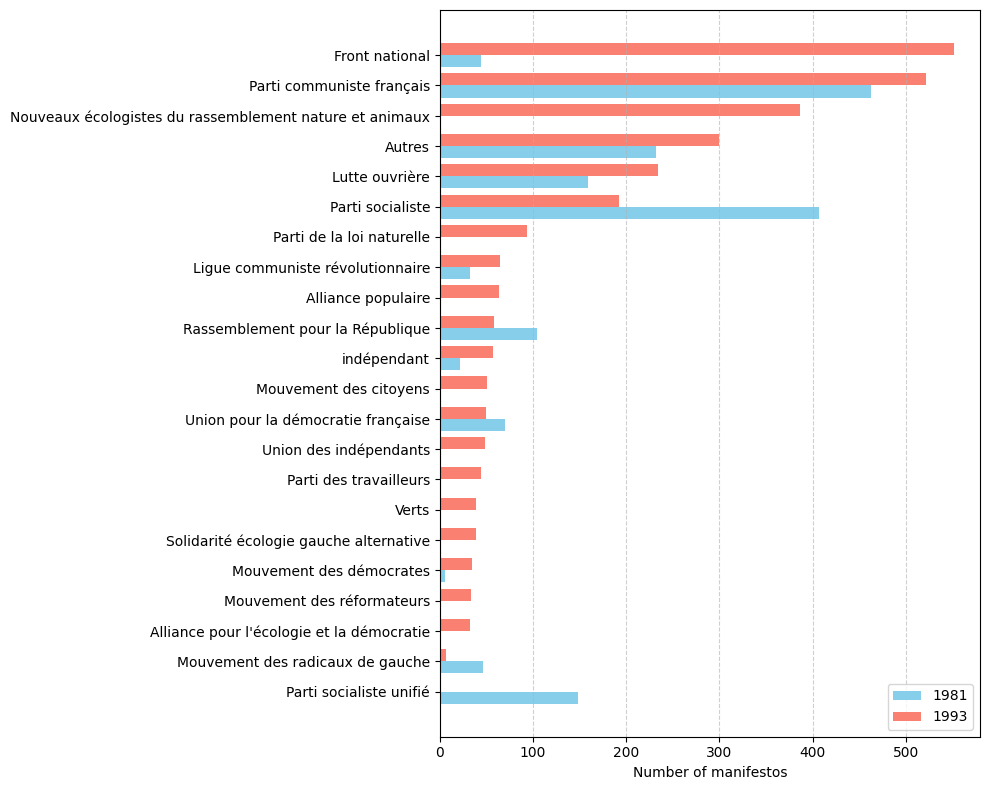

In [20]:
############## Comparative analysis of election manifestos (1981 vs 1993) for the report########

csv_path_81 = "/home/onyxia/work/NLP_rendus/.ipynb_checkpoints/data/legislatives_1981.csv"
csv_path_93 = "/home/onyxia/work/NLP_rendus/.ipynb_checkpoints/data/legislatives_1993.csv"

df_81 = pd.read_csv(csv_path_81, encoding="utf-8")
df_93 = pd.read_csv(csv_path_93, encoding="utf-8")

# Filter first round only
df81 = df_81[df_81['contexte-tour'] == 1].copy()
df93 = df_93[df_93['contexte-tour'] == 1].copy()

# Data cleaning
df_clean81 = df81[
    (~df81['titulaire-soutien'].str.contains(';', na=False)) &
    (df81['titulaire-soutien'] != 'non mentionné')
]

df_clean93 = df93[
    (~df93['titulaire-soutien'].str.contains(';', na=False)) &
    (~df93['titulaire-soutien'].isin(['non mentionné']))
]

# Count manifestos by party
counts81 = df_clean81['titulaire-soutien'].value_counts()
counts93 = df_clean93['titulaire-soutien'].value_counts()

# Comparative table
table = pd.concat([counts81, counts93], axis=1)
table.columns = ['1981', '1993']
table = table.fillna(0).astype(int)

# Keep major parties (at least 30 manifestos)
threshold = 30
major = table[(table['1981'] >= threshold) | (table['1993'] >= threshold)]
minor = table[(table['1981'] < threshold) & (table['1993'] < threshold)]

# Group minor parties as 'Others'
others = pd.DataFrame(minor.sum()).T
others.index = ['Autres']
table_final = pd.concat([major, others])

# Calculate percentages
table_final['% 1981'] = (table_final['1981'] / table_final['1981'].sum() * 100).round(1)
table_final['% 1993'] = (table_final['1993'] / table_final['1993'].sum() * 100).round(1)

# Sort by 1993 counts for better visualization
table_final = table_final.sort_values(by='1993', ascending=False)

#  Filter categories for the chart
df_filtered = table_final[(table_final['1981'] > 30) | (table_final['1993'] > 30)]
df_filtered = df_filtered.sort_values('1993', ascending=True)

#  Plot horizontal bar chart
plt.figure(figsize=(10, 8))

y = range(len(df_filtered))

plt.barh(y, df_filtered['1981'], height=0.4, label='1981', color='skyblue')
plt.barh([i + 0.4 for i in y], df_filtered['1993'], height=0.4, label='1993', color='salmon')

plt.yticks([i + 0.2 for i in y], df_filtered.index)

plt.xlabel("Number of manifestos")
#plt.title("Distribution of manifestos by party (1981 vs 1993)")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()